<a href="https://colab.research.google.com/github/maizoh/Project_Shinshu/blob/main/Project_Shinshu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

df_2024=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2024.csv",encoding="shift_jis"))
df_2024_selected=pd.DataFrame(df_2024.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

df_2023=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2023.csv",encoding="shift_jis"))
df_2023_selected=pd.DataFrame(df_2023.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

df_2022=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2022.csv",encoding="shift_jis"))
df_2022_selected=pd.DataFrame(df_2022.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

print(df_2024_selected.columns==df_2023_selected.columns,
df_2022_selected.columns==df_2023_selected.columns,
df_2022_selected.columns==df_2024_selected.columns)
df_2024_selected.columns

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True] [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True] [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


Index(['発生曜日', '発生時間帯', '発生場所', '概要', '当事者職種_1', '当事者職種経験（年数）_1',
       '当事者部署配属期間（年数）_1', '事例の内容', '事例の内容.1', '発生要因_当事者の行動に関わる要因',
       '発生要因_ヒューマンファクター', '発生要因_環境・設備機器', '発生要因_その他', '事例の背景要因の概要', '改善策'],
      dtype='object')

In [48]:
df_merged=pd.concat([df_2024_selected,df_2023_selected,df_2022_selected],axis=0,ignore_index=True)
df_merged.to_csv("/content/Medical_Data/df_merged_2.csv")

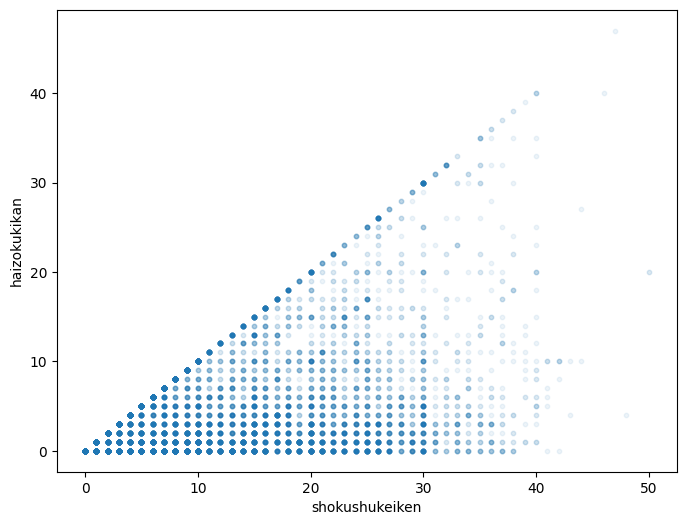

In [40]:
df_clean=df_merged.copy()

df_clean["当事者職種経験（年数）_1"]=df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1']=df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

df_clean = df_clean[df_clean['当事者職種経験（年数）_1'] >= df_clean['当事者部署配属期間（年数）_1']]

fig,ax=plt.subplots(figsize=(8,6))

x=df_clean["当事者職種経験（年数）_1"]
y=df_clean['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.08)
ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

plt.show()

薬剤ミスの解像度を高めていく。配属年数ごとのミスの違いとか、経験年数ごとのミスの違いとか

In [50]:
df_merged['当事者部署配属期間（年数）_1'].value_counts()

,count
当事者部署配属期間（年数）_1,
0年,6244
1年,3481
2年,2233
3年,1639
4年,1082
5年,781
6年,502
7年,420
10年,287
